In [2]:
import pandas as pd

# overview of the dataset
df = pd.read_csv('biosensor_dataset_with_target.csv')

df['Timestamp'] = pd.to_datetime(df['Timestamp'])

print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 10 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   Heart_Rate   1500 non-null   int64         
 1   Acc_X        1500 non-null   float64       
 2   Acc_Y        1500 non-null   float64       
 3   Acc_Z        1500 non-null   float64       
 4   Gyro_X       1500 non-null   float64       
 5   Gyro_Y       1500 non-null   float64       
 6   Gyro_Z       1500 non-null   float64       
 7   Event_Label  1500 non-null   object        
 8   Timestamp    1500 non-null   datetime64[ns]
 9   Athlete_ID   1500 non-null   object        
dtypes: datetime64[ns](1), float64(6), int64(1), object(2)
memory usage: 117.3+ KB
None


Event_Label
Start_Run       281
Stop            257
Jump_Takeoff    246
Sprint_Mid      245
Accel           241
Landing         230
Name: count, dtype: int64


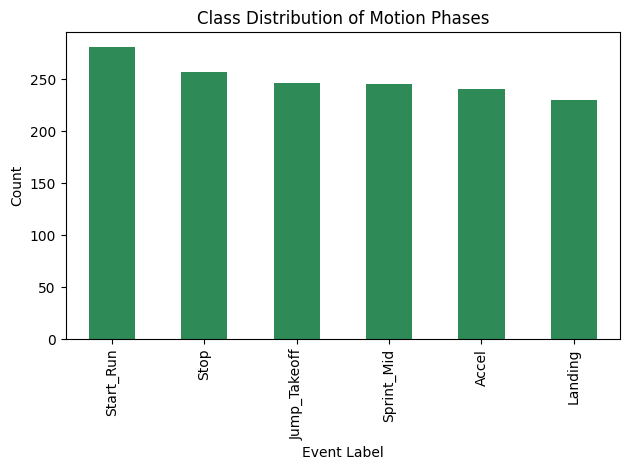

In [3]:
import matplotlib.pyplot as plt

# class distribution
counts = df['Event_Label'].value_counts()
print(counts)

counts.plot(kind='bar', color = 'seagreen')
plt.title('Class Distribution of Motion Phases')
plt.xlabel('Event Label')
plt.ylabel('Count')
plt.tight_layout()
plt.show()


In [4]:
# check for missing vals

print(df.isnull().sum())
print(df.isnull().sum().sum())

Heart_Rate     0
Acc_X          0
Acc_Y          0
Acc_Z          0
Gyro_X         0
Gyro_Y         0
Gyro_Z         0
Event_Label    0
Timestamp      0
Athlete_ID     0
dtype: int64
0


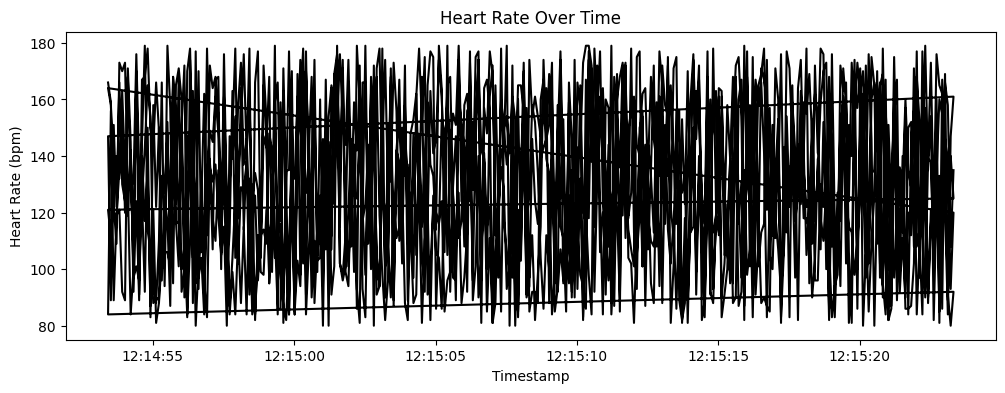

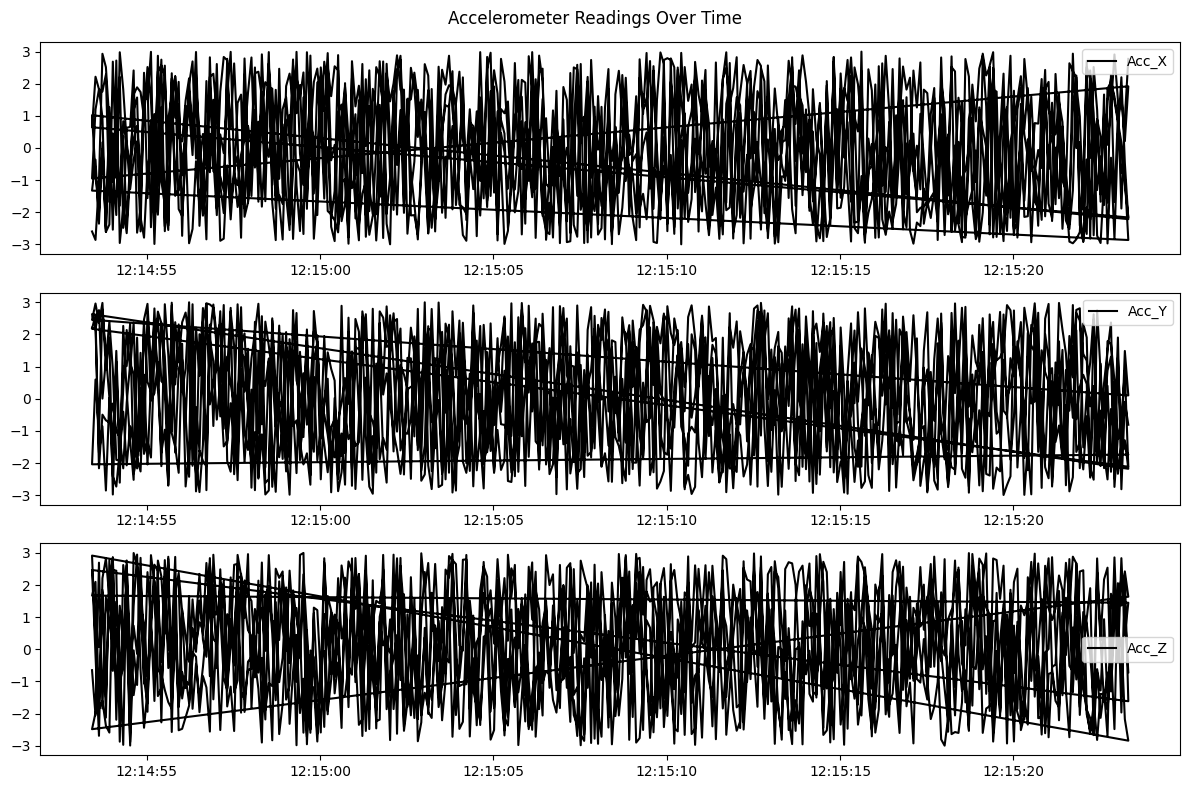

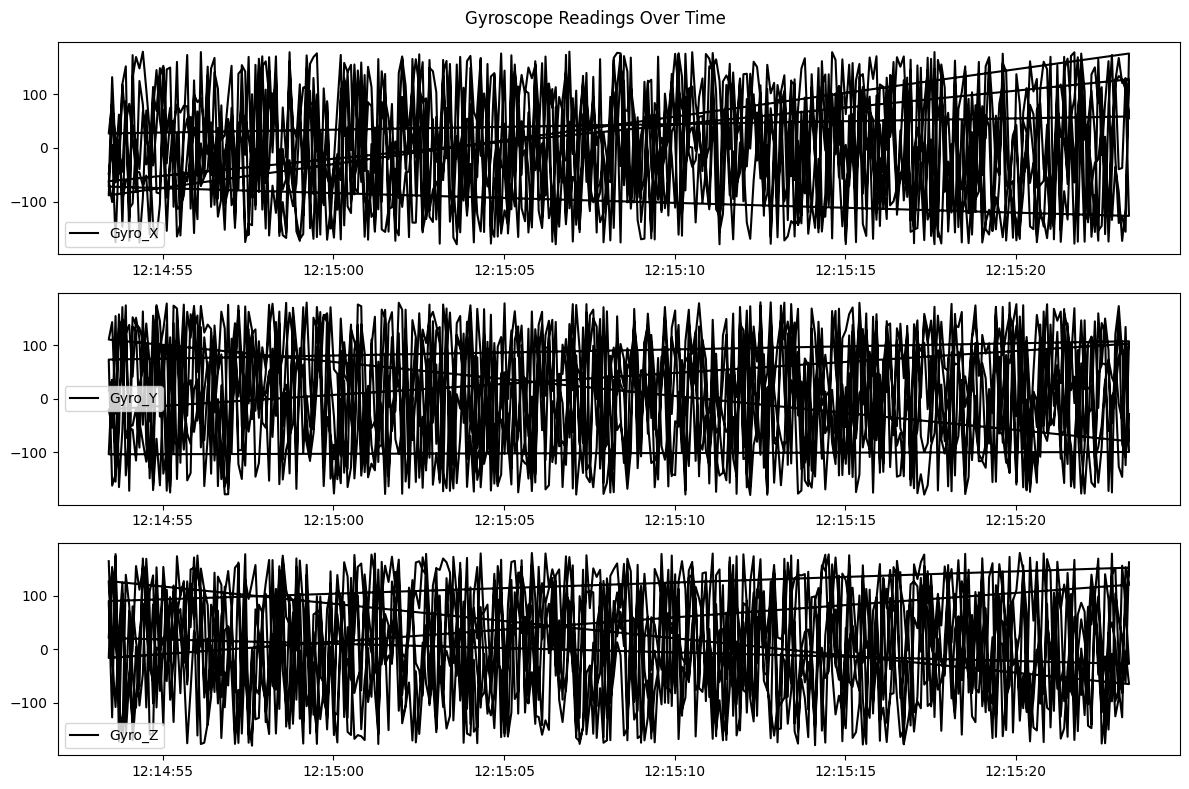

In [ ]:
import seaborn as sns

# heart rate over time
plt.figure(figsize=(12, 4))
plt.plot(df['Timestamp'], df['Heart_Rate'], color='green')
plt.title('Heart Rate Over Time')
plt.xlabel('Timestamp')
plt.ylabel('Heart Rate (bpm)')
plt.show()

# accelerometer signals over time
fig, axes = plt.subplots(3, 1, figsize=(12, 8))
for i, col in enumerate(['Acc_X', 'Acc_Y', 'Acc_Z']):
    axes[i].plot(df['Timestamp'], df[col], color = 'pink', label=col)
    axes[i].legend()
plt.suptitle('Accelerometer Readings Over Time')
plt.tight_layout()
plt.show()

# gyroscope signals over time
fig, axes = plt.subplots(3, 1, figsize=(12, 8))
for i, col in enumerate(['Gyro_X', 'Gyro_Y', 'Gyro_Z']):
    axes[i].plot(df['Timestamp'], df[col], color = 'blue', label=col)
    axes[i].legend()
plt.suptitle('Gyroscope Readings Over Time')
plt.tight_layout()
plt.show()


In [11]:
print("===== Summary Table: =====")
print("Number of participants:", df['Athlete_ID'].nunique())
print("Days per participant:", df.groupby('Athlete_ID').size().mean())
print(df.describe())
print(df.groupby('Event_Label').describe())


print("===== Note: There is no provided ethnic/age information for specific athlete demographics =====")
print("Motion type diversity:", df['Event_Label'].nunique(), "types")
print("Temporal diversity:", "Date range:", df['Timestamp'].min(), "to", df['Timestamp'].max())
print("Total labels:", df.shape[0])

===== Summary Table: =====
Number of participants: 5
Days per participant: 300.0
        Heart_Rate        Acc_X        Acc_Y        Acc_Z       Gyro_X  \
count  1500.000000  1500.000000  1500.000000  1500.000000  1500.000000   
mean    128.939333    -0.066879     0.026197     0.105689    -1.757905   
min      80.000000    -2.998485    -2.992459    -2.997461  -179.936814   
25%     104.000000    -1.647697    -1.532864    -1.301010   -90.409650   
50%     127.000000    -0.073829     0.028476     0.135645    -4.057885   
75%     155.000000     1.482475     1.545910     1.504561    87.400022   
max     179.000000     2.999229     2.999549     2.997938   179.890139   
std      29.116378     1.759208     1.742908     1.690009   104.943016   

            Gyro_Y       Gyro_Z                      Timestamp  
count  1500.000000  1500.000000                           1500  
mean      4.441275     4.349588  2025-05-11 12:15:08.367746816  
min    -179.996653  -179.888497     2025-05-11 12:14:53.4